In [24]:
# from google.colab import drive
# drive.mount('/content/drive')
# Datos cargados desde carpeta local 'data'

In [25]:
import pandas as pd

ruta = "data/diagnosis.csv/diagnosis.csv"
df_diagnosis = pd.read_csv(ruta)

print(df_diagnosis.head())

   subject_id   stay_id  seq_num icd_code  icd_version  \
0    10025463  35470228        1      431            9   
1    10027602  36678718        1      431            9   
2    10009049  31628990        1      486            9   
3    10014078  38676365        1     3453            9   
4    10007928  39661025        1     5780            9   

                        icd_title  
0        INTRACEREBRAL HEMORRHAGE  
1        INTRACEREBRAL HEMORRHAGE  
2  PNEUMONIA,ORGANISM UNSPECIFIED  
3                GRAND MAL STATUS  
4                     HEMATEMESIS  


In [26]:
ruta = "data/triage.csv/triage.csv"
df_triage = pd.read_csv(ruta)

print(df_triage.head())

   subject_id   stay_id  temperature  heartrate  resprate  o2sat  sbp  dbp  \
0    10016742  33211001          NaN        NaN       NaN    NaN  NaN  NaN   
1    10032725  30701739          NaN        NaN       NaN    NaN  NaN  NaN   
2    10010867  30115213          NaN        NaN       NaN    NaN  NaN  NaN   
3    10004235  38926302          NaN        NaN       NaN    NaN  NaN  NaN   
4    10027602  36678718          NaN        NaN       NaN    NaN  NaN  NaN   

  pain  acuity        chiefcomplaint  
0  NaN     NaN             PICC EVAL  
1  NaN     NaN          FACIAL DROOP  
2  NaN     NaN  MVC/INTUBATED TRAUMA  
3  NaN     NaN            S/P ARREST  
4  NaN     NaN            HEAD BLEED  


In [27]:
ruta = "data/edstays.csv/edstays.csv"
df_edstays = pd.read_csv(ruta)

print(df_edstays.head())

   subject_id     hadm_id   stay_id               intime              outtime  \
0    10014729  23300884.0  37887480  2125-03-19 12:36:00  2125-03-19 16:59:47   
1    10018328  26706939.0  34176810  2154-02-05 17:09:00  2154-02-05 22:54:00   
2    10018328         NaN  32103106  2154-08-03 15:31:00  2154-08-03 22:29:00   
3    10020640  27984218.0  38797992  2153-02-12 21:59:00  2153-02-13 01:38:00   
4    10015272  27993466.0  33473053  2137-06-12 16:54:00  2137-06-12 18:37:22   

  gender                    race arrival_transport disposition  
0      F  WHITE - OTHER EUROPEAN           WALK IN    ADMITTED  
1      F                   WHITE         AMBULANCE    ADMITTED  
2      F                   WHITE         AMBULANCE        HOME  
3      F                   WHITE         AMBULANCE    ADMITTED  
4      F                   WHITE         AMBULANCE    ADMITTED  


In [28]:
ruta = "data/medrecon.csv/medrecon.csv"
df_medrecon = pd.read_csv(ruta)

print(df_medrecon.head())

   subject_id   stay_id            charttime              name   gsn  \
0    10023117  31283645  2171-11-07 20:38:00          *acuvite     0   
1    10038999  34205403  2132-05-17 21:17:00      *depakote DR     0   
2    10002428  38216551  2160-07-15 19:43:00  *nutrient drink      0   
3    10016742  33335871  2178-07-22 06:08:00     *iron liquid      0   
4    10040025  32034003  2143-03-10 23:20:00       amoxicillin  8996   

           ndc  etc_rn  etccode              etcdescription  
0            0       1      NaN                         NaN  
1            0       1      NaN                         NaN  
2            0       1      NaN                         NaN  
3            0       1      NaN                         NaN  
4  10544054615       1      3.0  Aminopenicillin Antibiotic  


In [29]:
ruta = "data/pyxis.csv/pyxis.csv"
df_pyxis = pd.read_csv(ruta)

print(df_pyxis.head())

   subject_id   stay_id            charttime  med_rn     name  gsn_rn     gsn
0    10012853  36185653  2175-04-05 06:39:00       4  Aspirin       1  4380.0
1    10040025  37401157  2145-10-19 23:53:00       2  Aspirin       1  4380.0
2    10014354  30279522  2149-09-17 11:51:00       2  Aspirin       1  4380.0
3    10040025  30836087  2145-07-04 10:27:00      10  Aspirin       1  4380.0
4    10032725  30701739  2143-03-22 21:48:00       2  Aspirin       1  4376.0


Calculamos número de reingresos

In [30]:
df_edstays["intime"] = pd.to_datetime(df_edstays["intime"])
df_edstays["outtime"] = pd.to_datetime(df_edstays["outtime"])
df_edstays = df_edstays.sort_values(["subject_id", "intime"])
df_edstays["next_visit"] = df_edstays.groupby("subject_id")["intime"].shift(-1)
df_edstays["days_to_readmit"] = ( df_edstays["next_visit"] - df_edstays["outtime"]).dt.days
df_edstays["readmit_30d"] = df_edstays["days_to_readmit"] <= 30
df_edstays["readmit_30d"] = df_edstays["readmit_30d"].fillna(False)
df_edstays["readmit_30d"].value_counts()

readmit_30d
False    168
True      54
Name: count, dtype: int64

In [31]:
ruta = "data/vitalsign.csv/vitalsign.csv"
df_vitalsign = pd.read_csv(ruta)

print(df_vitalsign.head())

   subject_id   stay_id            charttime  temperature  heartrate  \
0    10014729  37887480  2125-03-19 13:22:00          NaN      124.0   
1    10014729  37887480  2125-03-19 18:28:00         98.9      106.0   
2    10014729  37887480  2125-03-19 13:07:00          NaN      128.0   
3    10014729  37887480  2125-03-19 16:23:00         99.8      115.0   
4    10014729  37887480  2125-03-19 13:24:00          NaN      125.0   

   resprate  o2sat    sbp   dbp             rhythm pain  
0      24.0  100.0   93.0  65.0                NaN  NaN  
1      18.0  100.0  115.0  70.0  Sinus Tachycardia    5  
2      18.0  100.0  132.0  96.0  Sinus Tachycardia  NaN  
3      22.0   97.0  114.0  45.0  Sinus Tachycardia    0  
4       NaN    NaN    NaN   NaN                NaN  NaN  


stay_id: An identifier which uniquely identifies a single emergency department stay for a single patient.

charttime: he time at which the vital signs were charted.

temperature: The patient’s temperature in degrees Farenheit. Some temperatures may be incorrectly documented as Celsius.

heartrate: The patient’s heart rate in beats per minute.

resprate: The patient’s respiratory rate in breaths per minute.

o2sat: The patient’s oxygen saturation measured as a percentage.

sbp, dbp: The patient’s systolic (sbp) and diastolic (dbp) blood pressure measured in millimetres of mercury (mmHg).

rhythm: The patient’s heart rhythm.

pain: The patient’s self-reported level of pain on a scale from 0-10. The pain is documented as free-text and may contain non-numeric entries.

Miro si hi ha els mateixos patient_id en diferents taules


In [32]:
comuns = len(set(df_edstays['subject_id']) & set(df_vitalsign['subject_id']))
print(comuns)

54


In [33]:
comuns = len(set(df_triage['subject_id']) & set(df_vitalsign['subject_id']))
print(comuns)

54


In [34]:
comuns = len(set(df_diagnosis['subject_id']) & set(df_vitalsign['subject_id']))
print(comuns)

53


In [35]:
comuns = len(set(df_triage['subject_id']) & set(df_edstays['subject_id']))
print(comuns)

64


# Análisis Exploratorio de Datos (EDA)

## 1. Análisis de la tabla DIAGNOSIS

In [36]:
print("="*60)
print("ANÁLISIS DE LA TABLA DIAGNOSIS")
print("="*60)
print(f"\n1. Dimensiones de la tabla:")
print(f"   - Filas: {df_diagnosis.shape[0]}")
print(f"   - Columnas: {df_diagnosis.shape[1]}")

print(f"\n2. Columnas disponibles:")
for col in df_diagnosis.columns:
    print(f"   - {col}")

print(f"\n3. Información general:")
df_diagnosis.info()

print(f"\n4. Valores nulos por columna:")
print(df_diagnosis.isnull().sum())

print(f"\n5. Valores únicos por columna:")
for col in df_diagnosis.columns:
    print(f"   - {col}: {df_diagnosis[col].nunique()} valores únicos")

print(f"\n6. Estadísticas descriptivas (columnas numéricas):")
print(df_diagnosis.describe())

print(f"\n7. Primeras filas:")
print(df_diagnosis.head(10))

ANÁLISIS DE LA TABLA DIAGNOSIS

1. Dimensiones de la tabla:
   - Filas: 545
   - Columnas: 6

2. Columnas disponibles:
   - subject_id
   - stay_id
   - seq_num
   - icd_code
   - icd_version
   - icd_title

3. Información general:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   subject_id   545 non-null    int64 
 1   stay_id      545 non-null    int64 
 2   seq_num      545 non-null    int64 
 3   icd_code     545 non-null    object
 4   icd_version  545 non-null    int64 
 5   icd_title    545 non-null    object
dtypes: int64(4), object(2)
memory usage: 25.7+ KB

4. Valores nulos por columna:
subject_id     0
stay_id        0
seq_num        0
icd_code       0
icd_version    0
icd_title      0
dtype: int64

5. Valores únicos por columna:
   - subject_id: 63 valores únicos
   - stay_id: 221 valores únicos
   - seq_num: 9 valores únicos
   - icd

         subject_id       stay_id     seq_num  icd_version
count  5.450000e+02  5.450000e+02  545.000000   545.000000
mean   1.002003e+07  3.532435e+07    2.222018     9.543119
std    1.241933e+04  3.019474e+06    1.397303     0.498595
min    1.000003e+07  3.009412e+07    1.000000     9.000000
25%    1.001285e+07  3.244379e+07    1.000000     9.000000
50%    1.001808e+07  3.554742e+07    2.000000    10.000000
75%    1.002641e+07  3.811255e+07    3.000000    10.000000
max    1.004002e+07  3.996872e+07    9.000000    10.000000

7. Primeras filas:
   subject_id   stay_id  seq_num icd_code  icd_version  \
0    10025463  35470228        1      431            9   
1    10027602  36678718        1      431            9   
2    10009049  31628990        1      486            9   
3    10014078  38676365        1     3453            9   
4    10007928  39661025        1     5780            9   
5    10019777  30952335        1     5789            9   
6    10006580  32259573        1     7231  

## 2. Análisis de la tabla TRIAGE

In [37]:
print("="*60)
print("ANÁLISIS DE LA TABLA TRIAGE")
print("="*60)
print(f"\n1. Dimensiones de la tabla:")
print(f"   - Filas: {df_triage.shape[0]}")
print(f"   - Columnas: {df_triage.shape[1]}")

print(f"\n2. Columnas disponibles:")
for col in df_triage.columns:
    print(f"   - {col}")

print(f"\n3. Información general:")
df_triage.info()

print(f"\n4. Valores nulos por columna:")
print(df_triage.isnull().sum())

print(f"\n5. Valores únicos por columna:")
for col in df_triage.columns:
    print(f"   - {col}: {df_triage[col].nunique()} valores únicos")

print(f"\n6. Estadísticas descriptivas (columnas numéricas):")
print(df_triage.describe())

print(f"\n7. Primeras filas:")
print(df_triage.head(10))

ANÁLISIS DE LA TABLA TRIAGE

1. Dimensiones de la tabla:
   - Filas: 222
   - Columnas: 11

2. Columnas disponibles:
   - subject_id
   - stay_id
   - temperature
   - heartrate
   - resprate
   - o2sat
   - sbp
   - dbp
   - pain
   - acuity
   - chiefcomplaint

3. Información general:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 222 entries, 0 to 221
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   subject_id      222 non-null    int64  
 1   stay_id         222 non-null    int64  
 2   temperature     196 non-null    float64
 3   heartrate       198 non-null    float64
 4   resprate        199 non-null    float64
 5   o2sat           198 non-null    float64
 6   sbp             199 non-null    float64
 7   dbp             199 non-null    float64
 8   pain            201 non-null    object 
 9   acuity          207 non-null    float64
 10  chiefcomplaint  222 non-null    object 
dtypes: float64(7), in

         subject_id       stay_id  temperature   heartrate    resprate  \
count  2.220000e+02  2.220000e+02   196.000000  198.000000  199.000000   
mean   1.001960e+07  3.533334e+07    97.785714   91.171717   18.135678   
std    1.226325e+04  2.996074e+06     4.484172   18.894062    3.007849   
min    1.000003e+07  3.009412e+07    36.500000   43.000000   14.000000   
25%    1.001285e+07  3.254778e+07    97.600000   77.000000   16.000000   
50%    1.001715e+07  3.546143e+07    98.100000   89.500000   18.000000   
75%    1.002633e+07  3.810308e+07    98.500000  104.000000   18.000000   
max    1.004002e+07  3.996872e+07   100.300000  157.000000   32.000000   

            o2sat         sbp         dbp      acuity  
count  198.000000  199.000000  199.000000  207.000000  
mean    97.691919  136.949749   77.040201    2.367150  
std      2.700072   27.830248   59.266121    0.653952  
min     78.000000   70.000000   42.000000    1.000000  
25%     97.000000  116.500000   62.000000    2.000000

## 3. Análisis de la tabla EDSTAYS

In [38]:
print("="*60)
print("ANÁLISIS DE LA TABLA EDSTAYS")
print("="*60)
print(f"\n1. Dimensiones de la tabla:")
print(f"   - Filas: {df_edstays.shape[0]}")
print(f"   - Columnas: {df_edstays.shape[1]}")

print(f"\n2. Columnas disponibles:")
for col in df_edstays.columns:
    print(f"   - {col}")

print(f"\n3. Información general:")
df_edstays.info()

print(f"\n4. Valores nulos por columna:")
print(df_edstays.isnull().sum())

print(f"\n5. Valores únicos por columna:")
for col in df_edstays.columns:
    print(f"   - {col}: {df_edstays[col].nunique()} valores únicos")

print(f"\n6. Estadísticas descriptivas (columnas numéricas):")
print(df_edstays.describe())

print(f"\n7. Distribución de reingresos a 30 días:")
print(df_edstays['readmit_30d'].value_counts())
print(f"\nPorcentaje de reingresos: {df_edstays['readmit_30d'].sum() / len(df_edstays) * 100:.2f}%")

print(f"\n8. Primeras filas:")
print(df_edstays.head(10))

ANÁLISIS DE LA TABLA EDSTAYS

1. Dimensiones de la tabla:
   - Filas: 222
   - Columnas: 12

2. Columnas disponibles:
   - subject_id
   - hadm_id
   - stay_id
   - intime
   - outtime
   - gender
   - race
   - arrival_transport
   - disposition
   - next_visit
   - days_to_readmit
   - readmit_30d

3. Información general:
<class 'pandas.core.frame.DataFrame'>
Index: 222 entries, 38 to 87
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   subject_id         222 non-null    int64         
 1   hadm_id            172 non-null    float64       
 2   stay_id            222 non-null    int64         
 3   intime             222 non-null    datetime64[ns]
 4   outtime            222 non-null    datetime64[ns]
 5   gender             222 non-null    object        
 6   race               222 non-null    object        
 7   arrival_transport  222 non-null    object        
 8   disposition        

## 4. Análisis de la tabla MEDRECON

In [39]:
print("="*60)
print("ANÁLISIS DE LA TABLA MEDRECON")
print("="*60)
print(f"\n1. Dimensiones de la tabla:")
print(f"   - Filas: {df_medrecon.shape[0]}")
print(f"   - Columnas: {df_medrecon.shape[1]}")

print(f"\n2. Columnas disponibles:")
for col in df_medrecon.columns:
    print(f"   - {col}")

print(f"\n3. Información general:")
df_medrecon.info()

print(f"\n4. Valores nulos por columna:")
print(df_medrecon.isnull().sum())

print(f"\n5. Valores únicos por columna:")
for col in df_medrecon.columns:
    print(f"   - {col}: {df_medrecon[col].nunique()} valores únicos")

print(f"\n6. Estadísticas descriptivas (columnas numéricas):")
print(df_medrecon.describe())

print(f"\n7. Primeras filas:")
print(df_medrecon.head(10))

ANÁLISIS DE LA TABLA MEDRECON

1. Dimensiones de la tabla:
   - Filas: 2764
   - Columnas: 9

2. Columnas disponibles:
   - subject_id
   - stay_id
   - charttime
   - name
   - gsn
   - ndc
   - etc_rn
   - etccode
   - etcdescription

3. Información general:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2764 entries, 0 to 2763
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   subject_id      2764 non-null   int64  
 1   stay_id         2764 non-null   int64  
 2   charttime       2764 non-null   object 
 3   name            2764 non-null   object 
 4   gsn             2764 non-null   int64  
 5   ndc             2764 non-null   int64  
 6   etc_rn          2764 non-null   int64  
 7   etccode         2760 non-null   float64
 8   etcdescription  2760 non-null   object 
dtypes: float64(1), int64(5), object(3)
memory usage: 194.5+ KB

4. Valores nulos por columna:
subject_id        0
stay_id           0
cha

## 5. Análisis de la tabla PYXIS

In [40]:
print("="*60)
print("ANÁLISIS DE LA TABLA PYXIS")
print("="*60)
print(f"\n1. Dimensiones de la tabla:")
print(f"   - Filas: {df_pyxis.shape[0]}")
print(f"   - Columnas: {df_pyxis.shape[1]}")

print(f"\n2. Columnas disponibles:")
for col in df_pyxis.columns:
    print(f"   - {col}")

print(f"\n3. Información general:")
df_pyxis.info()

print(f"\n4. Valores nulos por columna:")
print(df_pyxis.isnull().sum())

print(f"\n5. Valores únicos por columna:")
for col in df_pyxis.columns:
    print(f"   - {col}: {df_pyxis[col].nunique()} valores únicos")

print(f"\n6. Estadísticas descriptivas (columnas numéricas):")
print(df_pyxis.describe())

print(f"\n7. Primeras filas:")
print(df_pyxis.head(10))

ANÁLISIS DE LA TABLA PYXIS

1. Dimensiones de la tabla:
   - Filas: 1082
   - Columnas: 7

2. Columnas disponibles:
   - subject_id
   - stay_id
   - charttime
   - med_rn
   - name
   - gsn_rn
   - gsn

3. Información general:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1082 entries, 0 to 1081
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   subject_id  1082 non-null   int64  
 1   stay_id     1082 non-null   int64  
 2   charttime   1082 non-null   object 
 3   med_rn      1082 non-null   int64  
 4   name        1082 non-null   object 
 5   gsn_rn      1082 non-null   int64  
 6   gsn         1050 non-null   float64
dtypes: float64(1), int64(4), object(2)
memory usage: 59.3+ KB

4. Valores nulos por columna:
subject_id     0
stay_id        0
charttime      0
med_rn         0
name           0
gsn_rn         0
gsn           32
dtype: int64

5. Valores únicos por columna:
   - subject_id: 56 valores únicos
   -

## 6. Análisis de la tabla VITALSIGN

In [41]:
print("="*60)
print("ANÁLISIS DE LA TABLA VITALSIGN")
print("="*60)
print(f"\n1. Dimensiones de la tabla:")
print(f"   - Filas: {df_vitalsign.shape[0]}")
print(f"   - Columnas: {df_vitalsign.shape[1]}")

print(f"\n2. Columnas disponibles:")
for col in df_vitalsign.columns:
    print(f"   - {col}")

print(f"\n3. Información general:")
df_vitalsign.info()

print(f"\n4. Valores nulos por columna:")
print(df_vitalsign.isnull().sum())

print(f"\n5. Valores únicos por columna:")
for col in df_vitalsign.columns:
    print(f"   - {col}: {df_vitalsign[col].nunique()} valores únicos")

print(f"\n6. Estadísticas descriptivas (columnas numéricas):")
print(df_vitalsign.describe())

print(f"\n7. Primeras filas:")
print(df_vitalsign.head(10))

ANÁLISIS DE LA TABLA VITALSIGN

1. Dimensiones de la tabla:
   - Filas: 1038
   - Columnas: 11

2. Columnas disponibles:
   - subject_id
   - stay_id
   - charttime
   - temperature
   - heartrate
   - resprate
   - o2sat
   - sbp
   - dbp
   - rhythm
   - pain

3. Información general:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1038 entries, 0 to 1037
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   subject_id   1038 non-null   int64  
 1   stay_id      1038 non-null   int64  
 2   charttime    1038 non-null   object 
 3   temperature  579 non-null    float64
 4   heartrate    1008 non-null   float64
 5   resprate     990 non-null    float64
 6   o2sat        971 non-null    float64
 7   sbp          998 non-null    float64
 8   dbp          998 non-null    float64
 9   rhythm       33 non-null     object 
 10  pain         736 non-null    object 
dtypes: float64(6), int64(2), object(3)
memory usage: 89.3+ 

## 7. Resumen comparativo de todas las tablas

In [42]:
print("="*80)
print("RESUMEN COMPARATIVO DE TODAS LAS TABLAS")
print("="*80)

tablas = {
    'diagnosis': df_diagnosis,
    'triage': df_triage,
    'edstays': df_edstays,
    'medrecon': df_medrecon,
    'pyxis': df_pyxis,
    'vitalsign': df_vitalsign
}

resumen = []
for nombre, df in tablas.items():
    resumen.append({
        'Tabla': nombre,
        'Filas': df.shape[0],
        'Columnas': df.shape[1],
        'Pacientes únicos': df['subject_id'].nunique() if 'subject_id' in df.columns else 'N/A',
        'Visitas únicas': df['stay_id'].nunique() if 'stay_id' in df.columns else 'N/A',
        'Valores nulos (%)': f"{(df.isnull().sum().sum() / (df.shape[0] * df.shape[1]) * 100):.2f}%"
    })

df_resumen = pd.DataFrame(resumen)
print(df_resumen.to_string(index=False))

print("\n" + "="*80)
print("Pacientes comunes entre tablas:")
print("="*80)
if 'subject_id' in df_edstays.columns and 'subject_id' in df_vitalsign.columns:
    print(f"edstays ∩ vitalsign: {len(set(df_edstays['subject_id']) & set(df_vitalsign['subject_id']))} pacientes")
if 'subject_id' in df_triage.columns and 'subject_id' in df_vitalsign.columns:
    print(f"triage ∩ vitalsign: {len(set(df_triage['subject_id']) & set(df_vitalsign['subject_id']))} pacientes")
if 'subject_id' in df_diagnosis.columns and 'subject_id' in df_vitalsign.columns:
    print(f"diagnosis ∩ vitalsign: {len(set(df_diagnosis['subject_id']) & set(df_vitalsign['subject_id']))} pacientes")
if 'subject_id' in df_triage.columns and 'subject_id' in df_edstays.columns:
    print(f"triage ∩ edstays: {len(set(df_triage['subject_id']) & set(df_edstays['subject_id']))} pacientes")

RESUMEN COMPARATIVO DE TODAS LAS TABLAS
    Tabla  Filas  Columnas  Pacientes únicos  Visitas únicas Valores nulos (%)
diagnosis    545         6                63             221             0.00%
   triage    222        11                64             222             7.33%
  edstays    222        12                64             222             6.68%
 medrecon   2764         9                49             181             0.03%
    pyxis   1082         7                56             176             0.42%
vitalsign   1038        11                54             206            17.44%

Pacientes comunes entre tablas:
edstays ∩ vitalsign: 54 pacientes
triage ∩ vitalsign: 54 pacientes
diagnosis ∩ vitalsign: 53 pacientes
triage ∩ edstays: 64 pacientes


# Modelo Predictivo de Readmisión Hospitalaria

Objetivo: Predecir si un paciente será readmitido en los próximos 30 días tras el alta.

## 1. Importar librerías necesarias

In [43]:
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (classification_report, confusion_matrix, 
                             roc_auc_score, roc_curve, accuracy_score,
                             precision_score, recall_score, f1_score)
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("Librerías importadas correctamente")

Librerías importadas correctamente


## 2. Preparación y unión de datos

Vamos a combinar las diferentes tablas para crear un dataset completo con todas las características relevantes.

In [44]:
# Empezamos con la tabla base de edstays que contiene nuestra variable objetivo
print("Tabla base: edstays")
print(f"Filas: {len(df_edstays)}, Columnas: {len(df_edstays.columns)}")
print(f"Distribución de readmit_30d:")
print(df_edstays['readmit_30d'].value_counts())
print(f"Porcentaje de readmisión: {df_edstays['readmit_30d'].sum() / len(df_edstays) * 100:.2f}%")

Tabla base: edstays
Filas: 222, Columnas: 12
Distribución de readmit_30d:
readmit_30d
False    168
True      54
Name: count, dtype: int64
Porcentaje de readmisión: 24.32%


In [45]:
# Agregar información de signos vitales (agregados por stay_id)
# Calcularemos la media, min, max de cada signo vital por visita
vitalsign_agg = df_vitalsign.groupby('stay_id').agg({
    'temperature': ['mean', 'min', 'max', 'std'],
    'heartrate': ['mean', 'min', 'max', 'std'],
    'resprate': ['mean', 'min', 'max', 'std'],
    'o2sat': ['mean', 'min', 'max', 'std'],
    'sbp': ['mean', 'min', 'max', 'std'],
    'dbp': ['mean', 'min', 'max', 'std']
}).reset_index()

# Aplanar nombres de columnas
vitalsign_agg.columns = ['stay_id'] + [f'{col[0]}_{col[1]}' for col in vitalsign_agg.columns[1:]]

print(f"Features de signos vitales agregados: {len(vitalsign_agg.columns) - 1}")
print(vitalsign_agg.head())

Features de signos vitales agregados: 24
    stay_id  temperature_mean  temperature_min  temperature_max  \
0  30094124            97.900             97.3             98.5   
1  30115213            97.200             97.2             97.2   
2  30193781            99.275             97.8            101.0   
3  30225689            97.800             97.6             97.9   
4  30272878            97.400             97.4             97.4   

   temperature_std  heartrate_mean  heartrate_min  heartrate_max  \
0         0.848528            81.0           80.0           82.0   
1              NaN            86.0           83.0           89.0   
2         1.526161           108.8           88.0          122.0   
3         0.173205            69.6           60.0           77.0   
4         0.000000           131.0          122.0          141.0   

   heartrate_std  resprate_mean  ...  o2sat_max  o2sat_std    sbp_mean  \
0       1.414214          18.00  ...      100.0   0.707107  140.000000   

In [46]:
# Agregar información de triage
triage_features = df_triage[['stay_id', 'temperature', 'heartrate', 'resprate', 
                              'o2sat', 'sbp', 'dbp', 'pain', 'acuity']].copy()
triage_features.columns = ['stay_id', 'triage_temperature', 'triage_heartrate', 
                           'triage_resprate', 'triage_o2sat', 'triage_sbp', 
                           'triage_dbp', 'triage_pain', 'triage_acuity']

print(f"Features de triage: {len(triage_features.columns) - 1}")
print(triage_features.head())

Features de triage: 8
    stay_id  triage_temperature  triage_heartrate  triage_resprate  \
0  33211001                 NaN               NaN              NaN   
1  30701739                 NaN               NaN              NaN   
2  30115213                 NaN               NaN              NaN   
3  38926302                 NaN               NaN              NaN   
4  36678718                 NaN               NaN              NaN   

   triage_o2sat  triage_sbp  triage_dbp triage_pain  triage_acuity  
0           NaN         NaN         NaN         NaN            NaN  
1           NaN         NaN         NaN         NaN            NaN  
2           NaN         NaN         NaN         NaN            NaN  
3           NaN         NaN         NaN         NaN            NaN  
4           NaN         NaN         NaN         NaN            NaN  


In [47]:
# Contar número de diagnósticos, medicamentos y registros médicos por paciente
diagnosis_count = df_diagnosis.groupby('stay_id').size().reset_index(name='num_diagnoses')
medrecon_count = df_medrecon.groupby('stay_id').size().reset_index(name='num_medications')
pyxis_count = df_pyxis.groupby('stay_id').size().reset_index(name='num_pyxis_records')

print("Conteos agregados:")
print(f"- Diagnósticos por visita: {diagnosis_count.head()}")
print(f"- Medicamentos por visita: {medrecon_count.head()}")
print(f"- Registros Pyxis por visita: {pyxis_count.head()}")

Conteos agregados:
- Diagnósticos por visita:     stay_id  num_diagnoses
0  30094124              2
1  30115213              4
2  30193781              3
3  30225689              1
4  30272878              1
- Medicamentos por visita:     stay_id  num_medications
0  30094124               33
1  30225689               12
2  30279522               41
3  30373795               23
4  30667562               14
- Registros Pyxis por visita:     stay_id  num_pyxis_records
0  30094124                  5
1  30115213                  7
2  30193781                 12
3  30225689                  9
4  30272878                  4


In [48]:
# Crear duración de estancia en el ED (Emergency Department)
df_merge = df_edstays.copy()
df_merge['ed_stay_hours'] = (df_merge['outtime'] - df_merge['intime']).dt.total_seconds() / 3600

# Unir todas las tablas
df_merge = df_merge.merge(vitalsign_agg, on='stay_id', how='left')
df_merge = df_merge.merge(triage_features, on='stay_id', how='left')
df_merge = df_merge.merge(diagnosis_count, on='stay_id', how='left')
df_merge = df_merge.merge(medrecon_count, on='stay_id', how='left')
df_merge = df_merge.merge(pyxis_count, on='stay_id', how='left')

# Rellenar valores nulos en conteos con 0
df_merge['num_diagnoses'] = df_merge['num_diagnoses'].fillna(0)
df_merge['num_medications'] = df_merge['num_medications'].fillna(0)
df_merge['num_pyxis_records'] = df_merge['num_pyxis_records'].fillna(0)

print(f"\nDataset combinado:")
print(f"Filas: {len(df_merge)}")
print(f"Columnas: {len(df_merge.columns)}")
print(f"\nColumnas: {df_merge.columns.tolist()}")


Dataset combinado:
Filas: 222
Columnas: 48

Columnas: ['subject_id', 'hadm_id', 'stay_id', 'intime', 'outtime', 'gender', 'race', 'arrival_transport', 'disposition', 'next_visit', 'days_to_readmit', 'readmit_30d', 'ed_stay_hours', 'temperature_mean', 'temperature_min', 'temperature_max', 'temperature_std', 'heartrate_mean', 'heartrate_min', 'heartrate_max', 'heartrate_std', 'resprate_mean', 'resprate_min', 'resprate_max', 'resprate_std', 'o2sat_mean', 'o2sat_min', 'o2sat_max', 'o2sat_std', 'sbp_mean', 'sbp_min', 'sbp_max', 'sbp_std', 'dbp_mean', 'dbp_min', 'dbp_max', 'dbp_std', 'triage_temperature', 'triage_heartrate', 'triage_resprate', 'triage_o2sat', 'triage_sbp', 'triage_dbp', 'triage_pain', 'triage_acuity', 'num_diagnoses', 'num_medications', 'num_pyxis_records']


## 3. Selección de features y preparación para el modelo

In [49]:
# Seleccionar solo las columnas numéricas relevantes para el modelo
# Excluimos columnas identificadoras, fechas y la variable objetivo
exclude_cols = ['subject_id', 'hadm_id', 'stay_id', 'intime', 'outtime', 
                'next_visit', 'days_to_readmit', 'readmit_30d']

# Obtener columnas numéricas
numeric_cols = df_merge.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [col for col in numeric_cols if col not in exclude_cols]

print(f"Features seleccionadas ({len(feature_cols)}):")
for i, col in enumerate(feature_cols, 1):
    print(f"{i}. {col}")

# Verificar valores nulos en features
print(f"\nValores nulos en features:")
print(df_merge[feature_cols].isnull().sum().sort_values(ascending=False).head(10))

Features seleccionadas (35):
1. ed_stay_hours
2. temperature_mean
3. temperature_min
4. temperature_max
5. temperature_std
6. heartrate_mean
7. heartrate_min
8. heartrate_max
9. heartrate_std
10. resprate_mean
11. resprate_min
12. resprate_max
13. resprate_std
14. o2sat_mean
15. o2sat_min
16. o2sat_max
17. o2sat_std
18. sbp_mean
19. sbp_min
20. sbp_max
21. sbp_std
22. dbp_mean
23. dbp_min
24. dbp_max
25. dbp_std
26. triage_temperature
27. triage_heartrate
28. triage_resprate
29. triage_o2sat
30. triage_sbp
31. triage_dbp
32. triage_acuity
33. num_diagnoses
34. num_medications
35. num_pyxis_records

Valores nulos en features:
temperature_std       63
o2sat_std             37
heartrate_std         33
sbp_std               32
resprate_std          32
dbp_std               32
triage_temperature    26
triage_o2sat          24
triage_heartrate      24
triage_sbp            23
dtype: int64


In [50]:
# Preparar X (features) y y (target)
# Eliminar filas donde la variable objetivo es NaN
df_model = df_merge.dropna(subset=['readmit_30d']).copy()

X = df_model[feature_cols].copy()
y = df_model['readmit_30d'].astype(int)

# Imputar valores nulos en X con la mediana
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='median')
X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=X.columns, index=X.index)

print(f"Dataset para modelado:")
print(f"Filas: {len(X_imputed)}")
print(f"Features: {len(feature_cols)}")
print(f"\nDistribución de la variable objetivo:")
print(y.value_counts())
print(f"\nPorcentaje de clase positiva (readmit_30d=True): {y.sum() / len(y) * 100:.2f}%")

Dataset para modelado:
Filas: 222
Features: 35

Distribución de la variable objetivo:
readmit_30d
0    168
1     54
Name: count, dtype: int64

Porcentaje de clase positiva (readmit_30d=True): 24.32%


## 4. División de datos en train y test

In [51]:
# Dividir en train (80%) y test (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X_imputed, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Conjunto de entrenamiento: {len(X_train)} muestras")
print(f"Conjunto de prueba: {len(X_test)} muestras")
print(f"\nDistribución en train:")
print(y_train.value_counts())
print(f"\nDistribución en test:")
print(y_test.value_counts())

# Escalar las features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nDatos escalados y listos para entrenar modelos")

Conjunto de entrenamiento: 177 muestras
Conjunto de prueba: 45 muestras

Distribución en train:
readmit_30d
0    134
1     43
Name: count, dtype: int64

Distribución en test:
readmit_30d
0    34
1    11
Name: count, dtype: int64

Datos escalados y listos para entrenar modelos


## 5. Entrenamiento de modelos

Vamos a entrenar tres modelos diferentes y comparar su rendimiento:
- Regresión Logística
- Random Forest
- Gradient Boosting

In [52]:
# Modelo 1: Regresión Logística
print("="*60)
print("MODELO 1: REGRESIÓN LOGÍSTICA")
print("="*60)

lr_model = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')
lr_model.fit(X_train_scaled, y_train)

# Predicciones
y_pred_lr = lr_model.predict(X_test_scaled)
y_pred_proba_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

# Métricas
print(f"\nAccuracy: {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_lr):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_lr):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_lr):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba_lr):.4f}")

print("\nMatriz de Confusión:")
print(confusion_matrix(y_test, y_pred_lr))

print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred_lr))

MODELO 1: REGRESIÓN LOGÍSTICA

Accuracy: 0.6444
Precision: 0.3810
Recall: 0.7273
F1-Score: 0.5000
ROC-AUC: 0.5802

Matriz de Confusión:
[[21 13]
 [ 3  8]]

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.88      0.62      0.72        34
           1       0.38      0.73      0.50        11

    accuracy                           0.64        45
   macro avg       0.63      0.67      0.61        45
weighted avg       0.75      0.64      0.67        45



In [53]:
# Modelo 2: Random Forest
print("="*60)
print("MODELO 2: RANDOM FOREST")
print("="*60)

rf_model = RandomForestClassifier(
    n_estimators=100, 
    random_state=42, 
    class_weight='balanced',
    max_depth=10,
    min_samples_split=10
)
rf_model.fit(X_train, y_train)

# Predicciones
y_pred_rf = rf_model.predict(X_test)
y_pred_proba_rf = rf_model.predict_proba(X_test)[:, 1]

# Métricas
print(f"\nAccuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_rf):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_rf):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba_rf):.4f}")

print("\nMatriz de Confusión:")
print(confusion_matrix(y_test, y_pred_rf))

print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred_rf))

MODELO 2: RANDOM FOREST

Accuracy: 0.7556
Precision: 0.5000
Recall: 0.1818
F1-Score: 0.2667
ROC-AUC: 0.5722

Matriz de Confusión:
[[32  2]
 [ 9  2]]

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.78      0.94      0.85        34
           1       0.50      0.18      0.27        11

    accuracy                           0.76        45
   macro avg       0.64      0.56      0.56        45
weighted avg       0.71      0.76      0.71        45



In [54]:
# Modelo 3: Gradient Boosting
print("="*60)
print("MODELO 3: GRADIENT BOOSTING")
print("="*60)

gb_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)
gb_model.fit(X_train, y_train)

# Predicciones
y_pred_gb = gb_model.predict(X_test)
y_pred_proba_gb = gb_model.predict_proba(X_test)[:, 1]

# Métricas
print(f"\nAccuracy: {accuracy_score(y_test, y_pred_gb):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_gb):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_gb):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_gb):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba_gb):.4f}")

print("\nMatriz de Confusión:")
print(confusion_matrix(y_test, y_pred_gb))

print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred_gb))

MODELO 3: GRADIENT BOOSTING

Accuracy: 0.6889
Precision: 0.2857
Recall: 0.1818
F1-Score: 0.2222
ROC-AUC: 0.4786

Matriz de Confusión:
[[29  5]
 [ 9  2]]

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.76      0.85      0.81        34
           1       0.29      0.18      0.22        11

    accuracy                           0.69        45
   macro avg       0.52      0.52      0.51        45
weighted avg       0.65      0.69      0.66        45



## 6. Comparación de modelos

In [55]:
# Comparación de todos los modelos
models_comparison = pd.DataFrame({
    'Modelo': ['Regresión Logística', 'Random Forest', 'Gradient Boosting'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_gb)
    ],
    'Precision': [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_gb)
    ],
    'Recall': [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_gb)
    ],
    'F1-Score': [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_gb)
    ],
    'ROC-AUC': [
        roc_auc_score(y_test, y_pred_proba_lr),
        roc_auc_score(y_test, y_pred_proba_rf),
        roc_auc_score(y_test, y_pred_proba_gb)
    ]
})

print("="*80)
print("COMPARACIÓN DE MODELOS")
print("="*80)
print(models_comparison.to_string(index=False))

# Identificar el mejor modelo
best_model_idx = models_comparison['ROC-AUC'].idxmax()
best_model_name = models_comparison.loc[best_model_idx, 'Modelo']
print(f"\n🏆 Mejor modelo según ROC-AUC: {best_model_name}")

COMPARACIÓN DE MODELOS
             Modelo  Accuracy  Precision   Recall  F1-Score  ROC-AUC
Regresión Logística  0.644444   0.380952 0.727273  0.500000 0.580214
      Random Forest  0.755556   0.500000 0.181818  0.266667 0.572193
  Gradient Boosting  0.688889   0.285714 0.181818  0.222222 0.478610

🏆 Mejor modelo según ROC-AUC: Regresión Logística


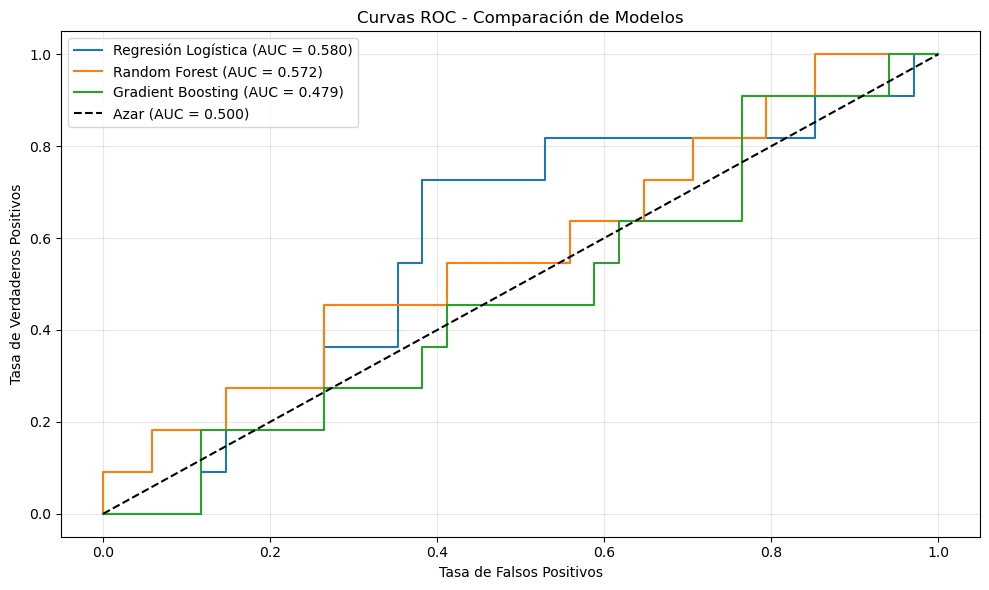

In [56]:
# Visualizar curvas ROC
plt.figure(figsize=(10, 6))

# Regresión Logística
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_pred_proba_lr)
plt.plot(fpr_lr, tpr_lr, label=f'Regresión Logística (AUC = {roc_auc_score(y_test, y_pred_proba_lr):.3f})')

# Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_proba_rf)
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_auc_score(y_test, y_pred_proba_rf):.3f})')

# Gradient Boosting
fpr_gb, tpr_gb, _ = roc_curve(y_test, y_pred_proba_gb)
plt.plot(fpr_gb, tpr_gb, label=f'Gradient Boosting (AUC = {roc_auc_score(y_test, y_pred_proba_gb):.3f})')

# Línea diagonal
plt.plot([0, 1], [0, 1], 'k--', label='Azar (AUC = 0.500)')

plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curvas ROC - Comparación de Modelos')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Importancia de características (Feature Importance)

Analicemos qué variables son más importantes para predecir la readmisión.

TOP 20 CARACTERÍSTICAS MÁS IMPORTANTES
           Feature  Importance
          dbp_mean    0.054084
           dbp_min    0.049584
   num_medications    0.046986
           sbp_min    0.045863
  temperature_mean    0.043143
     heartrate_std    0.038327
     resprate_mean    0.036328
   temperature_std    0.035642
     ed_stay_hours    0.034382
           dbp_std    0.032783
          sbp_mean    0.032700
           sbp_std    0.032559
         o2sat_std    0.031633
   temperature_min    0.031192
triage_temperature    0.030588
        triage_dbp    0.029834
        triage_sbp    0.029197
   temperature_max    0.029044
      resprate_std    0.028634
  triage_heartrate    0.027227


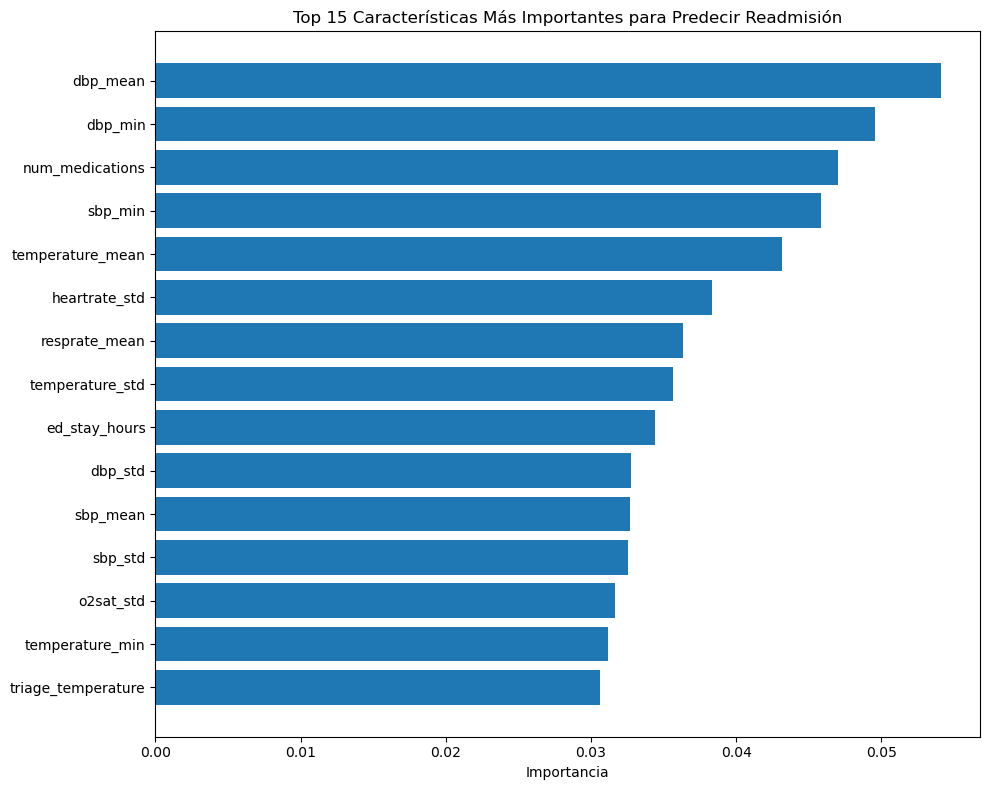

In [57]:
# Feature importance del mejor modelo de árbol (Random Forest o Gradient Boosting)
# Usaremos Random Forest para este análisis
feature_importance = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("="*60)
print("TOP 20 CARACTERÍSTICAS MÁS IMPORTANTES")
print("="*60)
print(feature_importance.head(20).to_string(index=False))

# Visualizar las 15 características más importantes
plt.figure(figsize=(10, 8))
top_features = feature_importance.head(15)
plt.barh(range(len(top_features)), top_features['Importance'])
plt.yticks(range(len(top_features)), top_features['Feature'])
plt.xlabel('Importancia')
plt.title('Top 15 Características Más Importantes para Predecir Readmisión')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 8. Conclusiones y Recomendaciones

Resumen del análisis predictivo de readmisiones hospitalarias.

In [58]:
print("="*80)
print("RESUMEN DEL ANÁLISIS PREDICTIVO")
print("="*80)

print(f"\n📊 Dataset:")
print(f"   - Total de visitas al ED: {len(df_model)}")
print(f"   - Readmisiones en 30 días: {y.sum()} ({y.sum()/len(y)*100:.2f}%)")
print(f"   - Features utilizados: {len(feature_cols)}")

print(f"\n🎯 Mejor Modelo: {best_model_name}")
best_metrics = models_comparison.iloc[best_model_idx]
print(f"   - ROC-AUC: {best_metrics['ROC-AUC']:.4f}")
print(f"   - Accuracy: {best_metrics['Accuracy']:.4f}")
print(f"   - Precision: {best_metrics['Precision']:.4f}")
print(f"   - Recall: {best_metrics['Recall']:.4f}")
print(f"   - F1-Score: {best_metrics['F1-Score']:.4f}")

print(f"\n📈 Top 5 Predictores de Readmisión:")
for i, row in feature_importance.head(5).iterrows():
    print(f"   {i+1}. {row['Feature']}: {row['Importance']:.4f}")

print("\n💡 Recomendaciones:")
print("   - Monitorear de cerca a pacientes con las características identificadas")
print("   - Implementar intervenciones preventivas basadas en los predictores clave")
print("   - Considerar seguimiento más intensivo para pacientes de alto riesgo")
print("   - Mejorar la recolección de datos para features con alta importancia")

print("\n" + "="*80)

RESUMEN DEL ANÁLISIS PREDICTIVO

📊 Dataset:
   - Total de visitas al ED: 222
   - Readmisiones en 30 días: 54 (24.32%)
   - Features utilizados: 35

🎯 Mejor Modelo: Regresión Logística
   - ROC-AUC: 0.5802
   - Accuracy: 0.6444
   - Precision: 0.3810
   - Recall: 0.7273
   - F1-Score: 0.5000

📈 Top 5 Predictores de Readmisión:
   22. dbp_mean: 0.0541
   23. dbp_min: 0.0496
   34. num_medications: 0.0470
   19. sbp_min: 0.0459
   2. temperature_mean: 0.0431

💡 Recomendaciones:
   - Monitorear de cerca a pacientes con las características identificadas
   - Implementar intervenciones preventivas basadas en los predictores clave
   - Considerar seguimiento más intensivo para pacientes de alto riesgo
   - Mejorar la recolección de datos para features con alta importancia

